# Email Spam Detection 
--- 

## Data Cleaning
---

In [69]:
# importing the required libraries  
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
# reading the dataset 
df = pd.read_csv('..\\datasets\\enron_spam_data.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(df.head())

   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  


#### Statistical summary of the dataset:
---

In [71]:
print("Description of the dataset (numeric):")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df.describe())


Description of the dataset (numeric):
       Message ID
count   33,716.00
mean    16,857.50
std      9,733.12
min          0.00
25%      8,428.75
50%     16,857.50
75%     25,286.25
max     33,715.00


In [72]:
print("\nDescription of the dataset (categorical):")
print(df.describe(include='str'))



Description of the dataset (categorical):
                                     Subject                     Message  \
count                                  33427                       33345   
unique                                 24206                       29779   
top     schedule crawler : hourahead failure  click here to be removed\n   
freq                                     185                          65   

       Spam/Ham        Date  
count     33716       33716  
unique        2        1527  
top        spam  2005-07-19  
freq      17171         457  


In [73]:
print("\nDataset information:")
print(df.info())



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB
None


In [74]:
print("\nNumber of missing values in each column:")
print(df.isnull().sum())


Number of missing values in each column:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64


In [75]:
# checking the duplicates rows
print(df.duplicated().sum())

0


---

In [76]:
df_clean = df

# removing the Student_ID column
df_clean = df_clean.drop(columns=["Message ID", "Date"])

In [77]:
# drop rows where either 'Subject' or 'Message' is NaN
df_clean = df_clean.dropna(subset=["Subject", "Message"])

In [78]:
df_clean.head()

,Subject,Message,Spam/Ham
1,"vastar resources , inc .","gary , production from the high island larger ...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
3,re : issue,fyi - see note below - already done .\nstella\...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham


In [79]:
# saving the cleaned csv into new csv file
df_clean.to_csv('..\\datasets\\email_data_cleaned.csv', index= False)

---

## EDA Exploratory Data Analysis
---

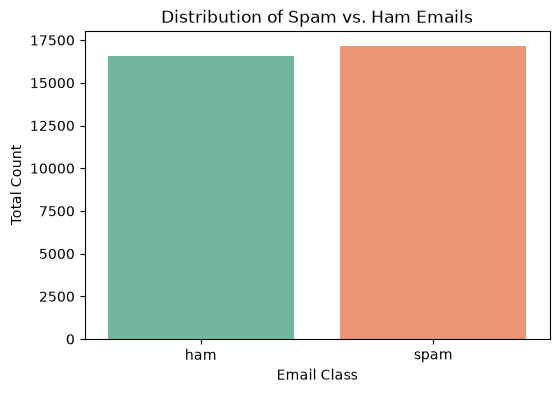

In [80]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Spam/Ham', hue='Spam/Ham', palette='Set2')
plt.title('Distribution of Spam vs. Ham Emails')
plt.xlabel('Email Class')
plt.ylabel('Total Count')
plt.show()

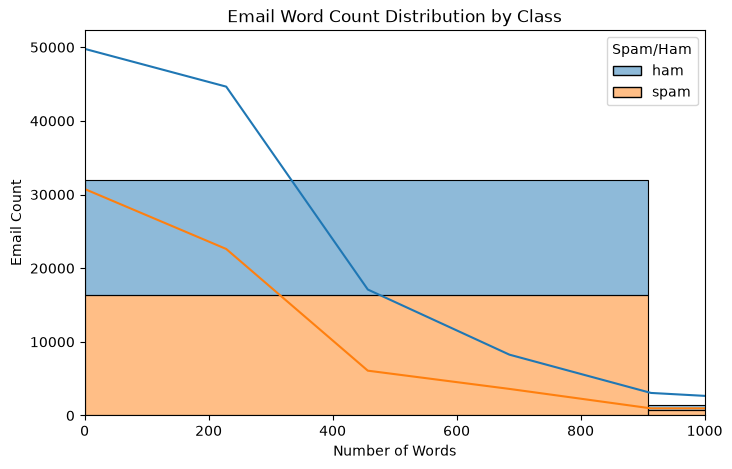

In [81]:
# Calculate word count feature
df['Message_Word_Count'] = df['Message'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 5))
# Using a log scale or xlim helps handle extremely long corporate outlier emails
sns.histplot(data=df, x='Message_Word_Count', hue='Spam/Ham', kde=True, bins=50, multiple='stack')
plt.xlim(0, 1000)  # Caps the view to emails under 1000 words for clarity
plt.title('Email Word Count Distribution by Class')
plt.xlabel('Number of Words')
plt.ylabel('Email Count')
plt.show()